##### 方法一

用最低位

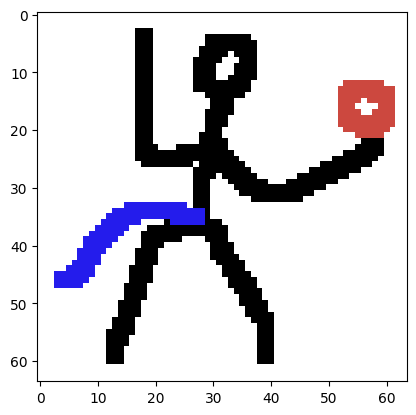

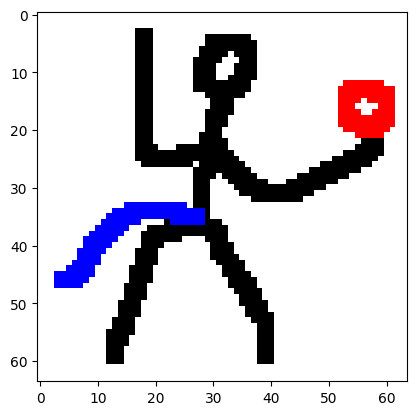

In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 方法一， 使用最低隐藏位
def hide_image(carrier_image_path, secret_image_path, output_image_path, show=False): # 隐藏函数，将秘密图像隐藏到载体图像中
    carrier = cv2.imread(carrier_image_path)    # 读取两张图片
    secret = cv2.imread(secret_image_path)
    if carrier.shape != secret.shape:   # 避免图片大小不同
        raise ValueError("Carrier and secret images must have the same shape.")
    
    carrier = carrier.astype(np.uint8)  # 图片矩阵类型转换
    secret = secret.astype(np.uint8)
    secret_bits = (secret >> 7 & 1)     # 取出秘密图像的最高位
    carrier = (carrier & 0xFE) | secret_bits    # 将秘密图像最高位隐藏到载体图像最低位
    cv2.imwrite(output_image_path, carrier) # 保存隐藏后的图像
    if show:    # 展示秘密图像
        plt.imshow(secret)
        plt.show()

def extract_image(hidden_image_path, output_secret_image_path, show=False):    # 提取函数，从隐藏图像中提取秘密图像
    hidden = cv2.imread(hidden_image_path)  # 读取隐藏图像
    secret_bits = hidden & 1    # 取出隐藏图像的最低位
    secret_image = secret_bits * 255    # 将最低位还原为秘密图像
    secret_image = secret_image.astype(np.uint8)    # 图像矩阵类型转换
    cv2.imwrite(output_secret_image_path, secret_image)   # 保存提取出的秘密图像
    if show:    # 展示提取出的秘密图像
        plt.imshow(secret_image)
        plt.show()


hide_image('./carrier_image.png', './secret_image.png', './hidden_image.png', True)
extract_image('./hidden_image.png', './extracted_secret_image.png', True)

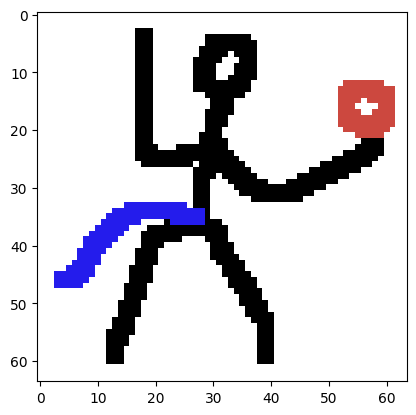

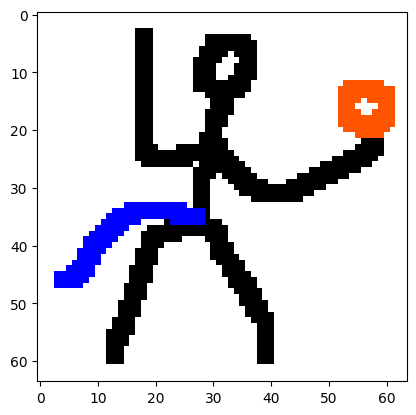

In [20]:
import numpy as np
import cv2
# 方法二， 使用两位隐藏位
def hide_image(carrier_image_path, secret_image_path, output_image_path, show=False):   # 隐藏函数，将秘密图像隐藏到载体图像中
    carrier = cv2.imread(carrier_image_path)    # 读取两张图片
    secret = cv2.imread(secret_image_path)
    if carrier.shape != secret.shape:   # 避免图片大小不同
        raise ValueError("Carrier and secret images must have the same shape.")
    
    carrier = carrier.astype(np.uint8)  # 图片矩阵类型转换
    secret = secret.astype(np.uint8)    
    secret_bits = secret >> 6   # 取出秘密图像的最高两位
    carrier = (carrier & 0xFC) | secret_bits    # 将秘密图像最高两位隐藏到载体图像最低两位
    cv2.imwrite(output_image_path, carrier) # 保存隐藏后的图像
    if show:    # 展示秘密图像
        plt.imshow(secret)
        plt.show()

def extract_image(hidden_image_path, output_secret_image_path, show=False):   # 提取函数，从隐藏图像中提取秘密图像
    hidden = cv2.imread(hidden_image_path)  # 读取隐藏图像
    secret_bits = hidden & 3    # 取出隐藏图像的最低两位
    secret_image = secret_bits * 85   # 将最低两位还原为秘密图像
    secret_image = secret_image.astype(np.uint8)    # 图像矩阵类型转换
    cv2.imwrite(output_secret_image_path, secret_image)  # 保存提取出的秘密图像
    if show:
        plt.imshow(secret_image)
        plt.show()


hide_image('./carrier_image.png', './secret_image.png', './hidden_image.png', True)
extract_image('./hidden_image.png', './extracted_secret_image.png', True)

255.0
204.0


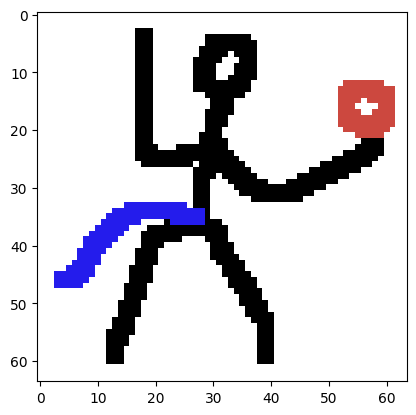

255
204
249.9
249


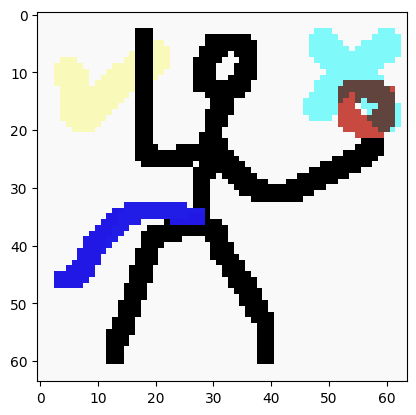

In [33]:
import numpy as np
import cv2
# 方法三，将秘密图像色值的0.1倍加到载体图像上，将秘密图像色值的0.1倍从载体图像减去。得到两张图片，将两张图片相加可以得到秘密图像的色值
def hide_image(carrier_image_path, secret_image_path, output_image_path1, output_image_path2, show=False):  # 隐藏函数，将秘密图像隐藏到载体图像中
    carrier = cv2.imread(carrier_image_path)    # 读取两张图片
    secret = cv2.imread(secret_image_path)
    if carrier.shape != secret.shape:   # 避免图片大小不同
        raise ValueError("Carrier and secret images must have the same shape.")
    
    carrier = carrier.astype(np.uint8)  # 图片矩阵类型转换
    secret = secret.astype(np.uint8)
    c1 = carrier * 0.9 + secret * 0.1   # 将秘密图像色值的0.1倍加到载体图像上
    c2 = carrier * 0.9 - secret * 0.1   # 将秘密图像色值的0.1倍从载体图像减去
    c1.astype(np.uint8) # 图像矩阵类型转换
    c2.astype(np.uint8)
    cv2.imwrite(output_image_path1, c1) # 保存隐藏后的图像
    cv2.imwrite(output_image_path2, c2) # 保存隐藏后的图像
    if show:    # 展示秘密图像
        plt.imshow(secret)
        plt.show()

def extract_image(hidden_image_path1, hidden_image_path2, output_secret_image_path, show=False):    # 提取函数，从隐藏图像中提取秘密图像
    hidden1 = cv2.imread(hidden_image_path1)    # 读取两张隐藏图像
    hidden2 = cv2.imread(hidden_image_path2)    
    secret_image = (hidden1 - hidden2) * 4.9    # 将两张隐藏图像相加可以得到秘密图像的色值（乘以一个小于5的数字避免溢出）
    secret_image = secret_image.astype(np.uint8)    # 图像矩阵类型转换
    cv2.imwrite(output_secret_image_path, secret_image)  # 保存提取出的秘密图像
    if show:    # 展示提取出的秘密图像
        plt.imshow(secret_image)
        plt.show()


hide_image('./carrier_image.png', './secret_image.png', './hidden_image1.png', './hidden_image2.png', True)
extract_image('./hidden_image1.png', './hidden_image2.png', './extracted_secret_image.png', True)